### Necessary Imports and Settings
    for any step in the following notebook

In [89]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cau_package_path = "../"
_normpath = os.path.normpath(cau_package_path)
if not os.path.normpath(_normpath) in sys.path:
    sys.path.append(_normpath)

import cmb_anomaly_utils as cau

In [90]:
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['text.usetex'] = True
plt.rc('font', family='serif')
plt.rc('legend', facecolor='white', edgecolor='k', framealpha=1)
plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['xtick.labelsize']  = 12
plt.rcParams['ytick.labelsize']  = 12

def custom_save_fig(fig, fdir, fname, do_plt_save = False):
    cau.output.ensure_dir(fdir)
    for ftype in ['.png', '.pdf']:
        fpath    = fdir + fname + ftype
        if not do_plt_save:
            fig.savefig(fpath, facecolor=(1,1,1,0), dpi=300, transparent=True)
        else:
            plt.savefig(fpath, dpi = 300, transparent = True)

In [91]:
cleaning_pipeline               = "commander"
run_inputs  = cau.run_utils.RunInputs()
run_inputs.max_sim_num          = 1000
common_cmb_data_path            = "../"
run_inputs.mask_fpath           = "{}/input/cmb_fits_files/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits".format(common_cmb_data_path)
run_inputs.cmb_fpath            = "{}/input/cmb_fits_files/COM_CMB_IQU-{}_2048_R3.00_full.fits".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.sims_path            = "{}/input/{}_sims/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.noise_path           = "{}/input/{}_noise/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.geom_flag            = cau.const.CAP_FLAG
run_inputs.measure_flag         = cau.const.SKEWNESS_FLAG
run_inputs.is_masked            = True
run_inputs.min_pix_ratio        = 0.1
run_inputs.nside                = 64
run_inputs.dir_nside            = 16
run_inputs.geom_start           = 0
run_inputs.geom_stop            = 180
run_inputs.delta_geom_samples   = 1
run_inputs.stripe_thickness     = 10
run_inputs.lmax                 = 30
run_inputs.ell_filter           = 5

base_path                       = "./output/{}_{}_min_pix_ratio_{:.1f}_ell_filter_{}/".format(
                                                                                    cleaning_pipeline,
                                                                                    run_inputs.nside,
                                                                                    run_inputs.min_pix_ratio,
                                                                                    run_inputs.ell_filter)
# base_path                       = "./output/{}_{}_min_pix_ratio_{:.1f}/".format(
#                                                                                     cleaning_pipeline,
#                                                                                     run_inputs.nside,
#                                                                                     run_inputs.min_pix_ratio)
plot_path                       = base_path.replace("output/", "plot/")
for _path in [base_path, plot_path]: cau.output.ensure_dir(_path)

map_disc_sizes = cau.stat_utils.get_range(10, 90, 5)
# map_disc_sizes = np.concatenate((cau.stat_utils.get_range(4, 9, 1), cau.stat_utils.get_range(10, 90, 5)))
max_sim_num = run_inputs.max_sim_num

### Peparing Temperature Maps

In [8]:
print("Warming Up!")

map_gen = cau.run_utils.MapGenerator(**run_inputs.to_kwargs())

dummy_map = map_gen.create_dummy_map()
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
ndir = cau.coords.get_npix(run_inputs.dir_nside)
measure_dir_indices = np.arange(ndir, dtype=int)

cmb_measure = np.zeros(ndir)
sims_measure = np.zeros((max_sim_num, ndir))

print("Reading CMB Data:")
cmb_map = map_gen.create_cmb_map()
cau.map_utils.remove_monopole_dipole(cmb_map)
cau.map_utils.apply_butterworth_hpf(cmb_map, run_inputs.ell_filter)
print("\t-Done-")

print("Providing Simulations:")
sims_maps: list[cau.dtypes.PixMap] = []
for sim_num in range(max_sim_num):
    print("\t{:04}/{:04}\r".format(sim_num + 1, max_sim_num), end="")
    sim_pix_map = map_gen.create_sim_map_from_txt(sim_num, use_noise=False)
    cau.map_utils.remove_monopole_dipole(sim_pix_map)
    cau.map_utils.apply_butterworth_hpf(sim_pix_map, run_inputs.ell_filter)
    sims_maps.append(sim_pix_map)
print("")

Warming Up!
Reading CMB Data:
	-Done-
Providing Simulations:
	1000/1000


### Calculation of Disc (RAW)Measure
    "Pepare Temperature Maps" Section is needed in memory

In [15]:
for disc_size in map_disc_sizes:
    print("Disc Size(deg): {:2}".format(disc_size))
    print("Calculating Cap Measures:")
    for dir_i in measure_dir_indices:
        print(f"\t{dir_i}/{ndir - 1}\r", end="")
        # Separating Common Geometry -> Top cap & Bottom cap
        plat, plon = dir_lat[dir_i], dir_lon[dir_i]
        dummy_map.change_pole(plat, plon)
        top_filter, bottom_filter = cau.geometry.get_top_bottom_caps_selection_filters( pix_map = dummy_map,
                                                                                        cap_angle = disc_size)
        top_cap, bottom_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = cmb_map,
                                                                           top_sel = top_filter,
                                                                           bottom_sel = bottom_filter)
        visible_ratio = top_cap.get_visible_pixels_ratio()
        # CMB measure
        cmb_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                cau.measure.func_dict[run_inputs.measure_flag](top_cap, bottom_cap, **run_inputs.to_kwargs())
        # Simulation Measure
        for sim_num in range(max_sim_num):
            top_cap, bottom_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = sims_maps[sim_num],
                                                                               top_sel = top_filter,
                                                                               bottom_sel = bottom_filter)
            sims_measure[sim_num, dir_i] = \
                np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                    cau.measure.func_dict[run_inputs.measure_flag](top_cap, bottom_cap, **run_inputs.to_kwargs())
    print("")
    
    _mflag = run_inputs.measure_flag.lower()
    _series = cleaning_pipeline
    np.savetxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt", cmb_measure)
    np.savetxt(base_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt", sims_measure)

# print("-Done-")

Disc Size(deg): 10.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 15.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 20.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 25.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 30.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 35.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 40.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 45.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 50.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 55.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 60.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 65.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 70.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 75.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 80.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 85.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 90.0
Calculating Cap Measures:
	3071/3071


#### Finding Dipole Direction/Amplitude on Cap-Measure Maps Considering $Mean(Measure) \; \& \; Var(Measure)$
    "Calculate Cap (RAW)Measures" Section has to be computed and stored

In [6]:
n_cap_sizes = len(map_disc_sizes)

# The directions that we measure towards
cmb_directions = np.zeros((n_cap_sizes))
sims_directions = np.zeros((n_cap_sizes, max_sim_num))
cmb_amplitides = np.zeros((n_cap_sizes))
sims_amplitudes = np.zeros((n_cap_sizes, max_sim_num))

dummy_map = cau.dtypes.PixMap.create_dummy(run_inputs.dir_nside)

_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

for ds_i, disc_size in enumerate(map_disc_sizes):
    cmb_msr  = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    sims_msr = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt")

    #----COMMON ASSETS----
    # Common Mean and Var of Simulated Maps
    _mean = np.mean(sims_msr, axis = 0)
    _var  = np.var(sims_msr, axis = 0)
    # Common Mask
    _mask = np.isnan(cmb_msr)
    dummy_map.mask = _mask if np.any(_mask) else None
    
    #----SPECIFIC CALCULATIONS----
    # CMB Direction
    dummy_map.data = (cmb_msr - _mean) / _var
    cmb_directions[ds_i] = cau.map_utils.get_dipole_direction_index(pix_map = dummy_map,
                                                                    dir_nside = run_inputs.dir_nside)
    cmb_amplitides[ds_i] = cau.map_utils.get_dipole_amplitude(pix_map=dummy_map)
    # Simulations Directions
    for sim_num in range(max_sim_num):
        dummy_map.data = (sims_msr[sim_num] - _mean) / _var
        sims_directions[ds_i, sim_num] = \
            cau.map_utils.get_dipole_direction_index(pix_map = dummy_map,
                                                     dir_nside = run_inputs.dir_nside)
        sims_amplitudes[ds_i, sim_num] = cau.map_utils.get_dipole_amplitude(pix_map=dummy_map)
        

np.savetxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", cmb_directions, fmt = '%i')
np.savetxt(base_path + f"{_series}_sims_{_mflag}_dir.txt", sims_directions, fmt = '%i')

np.savetxt(base_path + f"{_series}_cmb_{_mflag}_amp.txt", cmb_amplitides)
np.savetxt(base_path + f"{_series}_sims_{_mflag}_amp.txt", sims_amplitudes)

#### Direction analysis
Here we check if the directions have any correlations to the local variance dipole direcion 

In [110]:
# Direction of Doppler boost for CMB sky
lon_beta = 263.99
lat_beta = 48.26
beta_dir    = cau.coords.convert_polar_to_xyz(lat_beta, lon_beta)
# Direction of beta cross, the one which is perpendicular to boost direction, but is parallel to galactic plane
beta_cross  = np.cross(np.array([0,0,1]), beta_dir)
beta_cross  = cau.coords.normalize_vec(beta_cross)
# The third direction, perpendicular to the last two
beta_perp   = np.cross(beta_dir, beta_cross)

def simplify_nd_vec(nd_arr):
    return [round(float(elem[0]), 2) for elem in nd_arr]
print(simplify_nd_vec(cau.coords.convert_xyz_to_polar(beta_dir)))
print(simplify_nd_vec(cau.coords.convert_xyz_to_polar(beta_cross)))
print(simplify_nd_vec(cau.coords.convert_xyz_to_polar(beta_perp)))

[48.26, 263.99]
[0.0, 353.99]
[41.74, 83.99]


#### Angle Skewness dipole & Variance dipole 

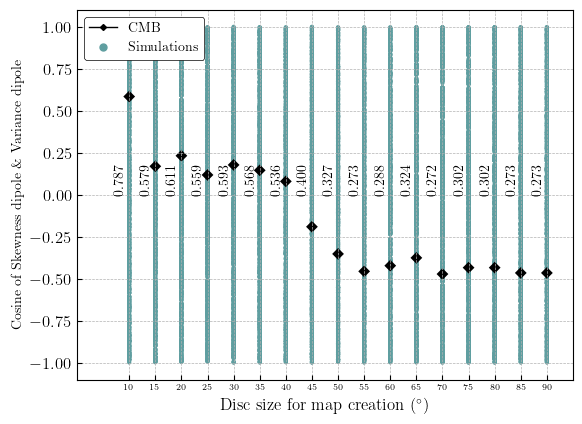

In [117]:
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

cmb_skew_dir_i    = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", dtype = int)
sims_skew_dir_i   = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_dir.txt", dtype = int)

var_path            = "../cmb_local_variance_higher_multipoles/output/commander_64_min_pix_ratio_0.1/"
cmb_var_dir_i       = np.loadtxt(var_path + "commander_cmb_var_dir.txt", dtype = int)
sims_var_dir_i      = np.loadtxt(var_path + "commander_sims_var_dir.txt", dtype = int)

p_values        = np.zeros(len(map_disc_sizes))

with plt.style.context('bmh'):
    fig, ax = plt.subplots()
    
    for ds_i, disc_size in enumerate(map_disc_sizes):
        # CMB angle analysis
        lat_skew, lon_skew  = dir_lat[cmb_skew_dir_i[ds_i]], dir_lon[cmb_skew_dir_i[ds_i]]
        lat_var, lon_var    = dir_lat[cmb_var_dir_i[ds_i]], dir_lon[cmb_var_dir_i[ds_i]]
        cmb_skew_beta_angle = cau.coords.get_angular_dist_polar((lat_skew, lon_skew), (lat_var, lon_var))
        
        # Simulations angle analysis
        for sim_num in range(max_sim_num):
            lat_skew, lon_skew  = dir_lat[sims_skew_dir_i[ds_i, sim_num]], dir_lon[sims_skew_dir_i[ds_i, sim_num]]

            sim_skew_beta_angle = cau.coords.get_angular_dist_polar((lat_skew, lon_skew), (lat_var, lon_var))
            if cmb_skew_beta_angle < sim_skew_beta_angle:
                p_values[ds_i] += 1
            ax.scatter(disc_size, np.cos(np.radians(sim_skew_beta_angle)),
                        marker='.', edgecolors='none', linewidths=.5, c='cadetblue', alpha=1)

        ax.scatter(disc_size, np.cos(np.radians(cmb_skew_beta_angle)),
                    marker='D', edgecolors='none', linewidths=.5, c='k', alpha=1)
        
        p_values[ds_i] /= max_sim_num
        ax.text(x=disc_size - 3, y = 0,
                s = "{:0.3f}".format(p_values[ds_i]), rotation=90)

    ax.set_xlabel(r"Disc size for map creation $(^\circ)$")
    ax.set_ylabel(r"\normalsize{Cosine of Skewness dipole \& Variance dipole}")
    # ax.set_title(r"")
    sample_curves = [
        Line2D([0], [0], ls='-',    color='k',     lw=1, marker='D', markersize=3),
        Line2D([0], [0], ls='none', color='cadetblue',  lw=1, marker='.', markersize=10),
        ]
    ax.legend(  sample_curves, [
                    "CMB",
                    "Simulations",
                ],
                loc=2)
    ax.tick_params(axis='x', which='major', labelsize=6)
    ax.set_xlim(xmin = 0, xmax = 95)
    ax.set_ylim(ymin = -1.1, ymax = 1.1)
    ax.set_xticks(map_disc_sizes)
    ax.set_facecolor('white')
    # Axis colors
    for spine in ax.spines.keys(): ax.spines[spine].set_color('k')
    custom_save_fig(fig,
                    fdir = plot_path,
                    fname = "angle_skewness_variance".format(run_inputs.ell_filter),
                    do_plt_save = False)
    plt.show()


#### Angle between Skewness dipole & Doppler direction

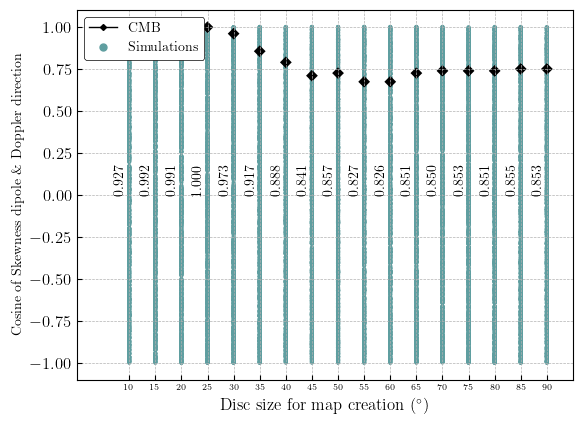

In [118]:
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

cmb_skew_dir_i    = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", dtype = int)
sims_skew_dir_i   = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_dir.txt", dtype = int)

p_values        = np.zeros(len(map_disc_sizes))

with plt.style.context('bmh'):
    fig, ax = plt.subplots()
    
    for ds_i, disc_size in enumerate(map_disc_sizes):
        # CMB angle analysis
        lat_skew, lon_skew  = dir_lat[cmb_skew_dir_i[ds_i]], dir_lon[cmb_skew_dir_i[ds_i]]
        cmb_skew_beta_angle = cau.coords.get_angular_dist_polar((lat_skew, lon_skew), (lat_beta, lon_beta))
        
        # Simulations angle analysis
        for sim_num in range(max_sim_num):
            lat_skew, lon_skew  = dir_lat[sims_skew_dir_i[ds_i, sim_num]], dir_lon[sims_skew_dir_i[ds_i, sim_num]]

            sim_skew_beta_angle = cau.coords.get_angular_dist_polar((lat_skew, lon_skew), (lat_beta, lon_beta))
            if cmb_skew_beta_angle < sim_skew_beta_angle:
                p_values[ds_i] += 1
            ax.scatter(disc_size, np.cos(np.radians(sim_skew_beta_angle)),
                        marker='.', edgecolors='none', linewidths=.5, c='cadetblue', alpha=1)

        ax.scatter(disc_size, np.cos(np.radians(cmb_skew_beta_angle)),
                    marker='D', edgecolors='none', linewidths=.5, c='k', alpha=1)
        
        p_values[ds_i] /= max_sim_num
        ax.text(x=disc_size - 3, y = 0,
                s = "{:0.3f}".format(p_values[ds_i]), rotation=90)

    ax.set_xlabel(r"Disc size for map creation $(^\circ)$")
    ax.set_ylabel(r"\normalsize{Cosine of Skewness dipole \& Doppler direction}")
    # ax.set_title(r"")
    sample_curves = [
        Line2D([0], [0], ls='-',    color='k',     lw=1, marker='D', markersize=3),
        Line2D([0], [0], ls='none', color='cadetblue',  lw=1, marker='.', markersize=10),
        ]
    ax.legend(  sample_curves, [
                    "CMB",
                    "Simulations",
                ],
                loc=2)
    ax.tick_params(axis='x', which='major', labelsize=6)
    ax.set_xlim(xmin = 0, xmax = 95)
    ax.set_ylim(ymin = -1.1, ymax = 1.1)
    ax.set_xticks(map_disc_sizes)
    ax.set_facecolor('white')
    # Axis colors
    for spine in ax.spines.keys(): ax.spines[spine].set_color('k')
    custom_save_fig(fig,
                    fdir = plot_path,
                    fname = "angle_skewness_doppler_dir".format(run_inputs.ell_filter),
                    do_plt_save = False)
    plt.show()

### $LocalMeasure$ Maps

#### Plotting

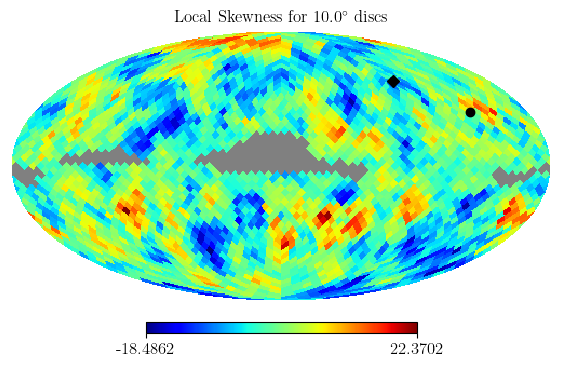

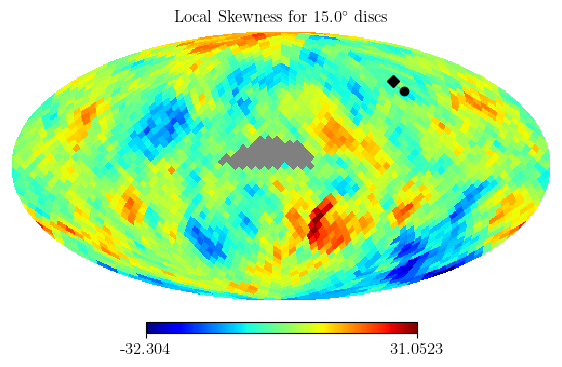

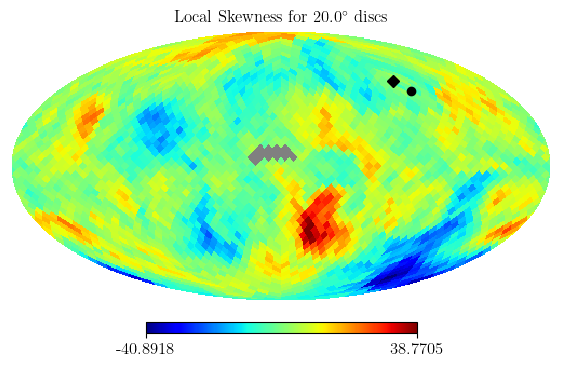

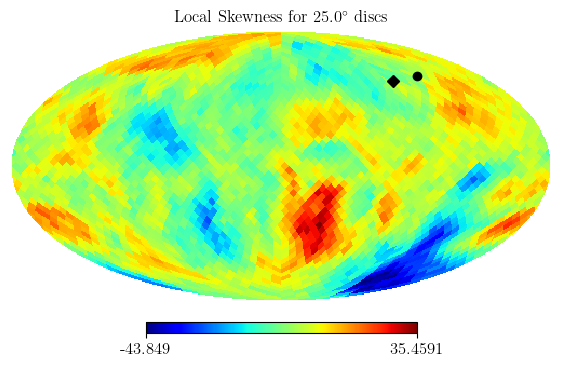

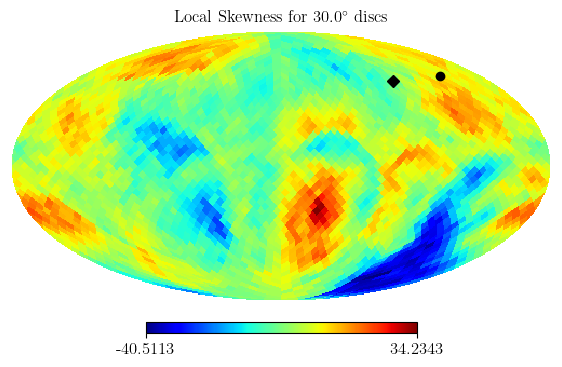

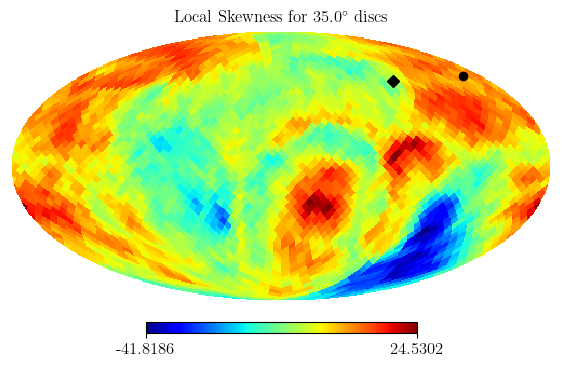

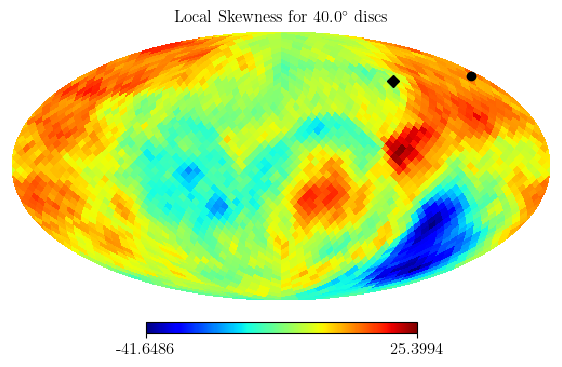

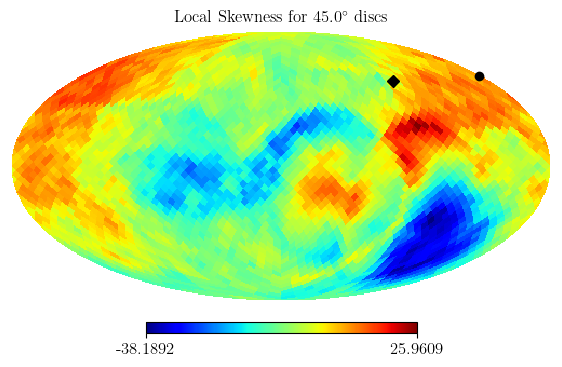

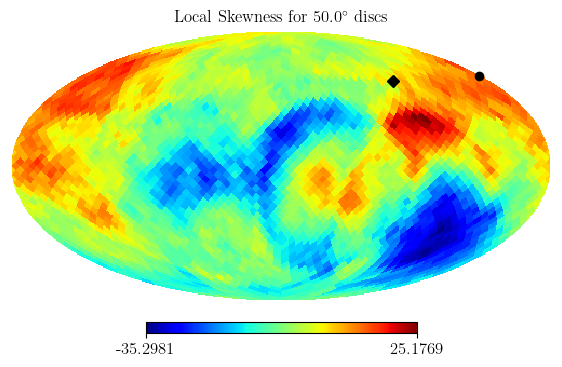

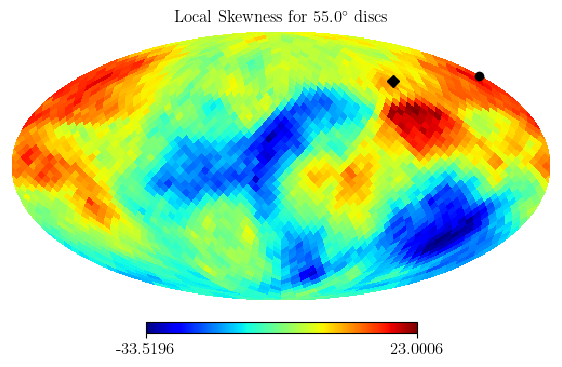

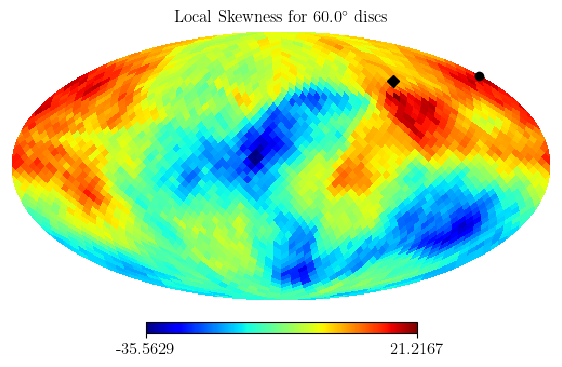

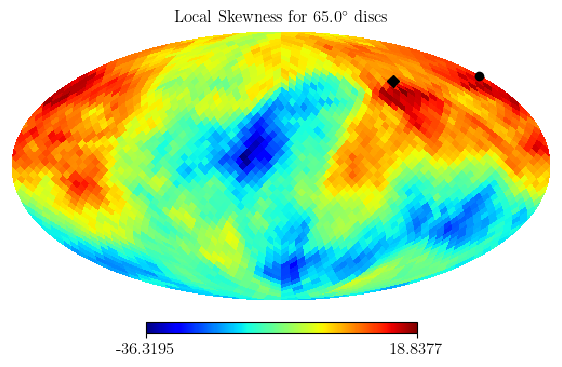

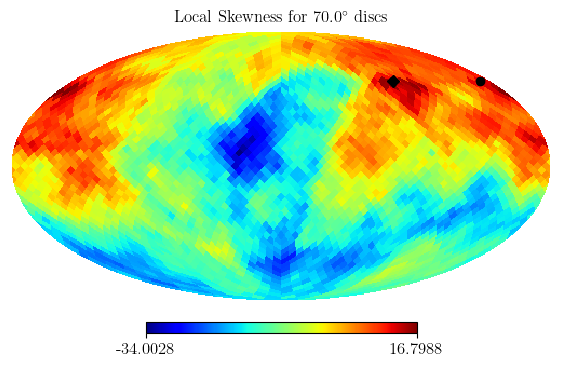

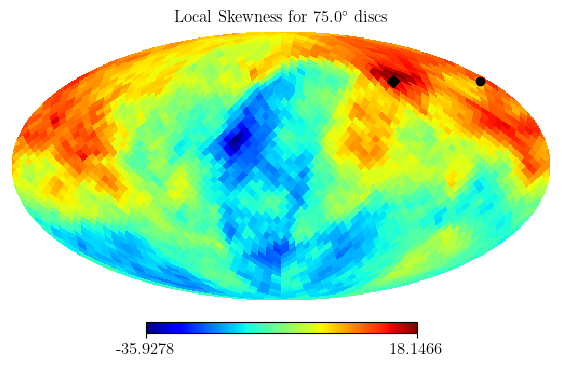

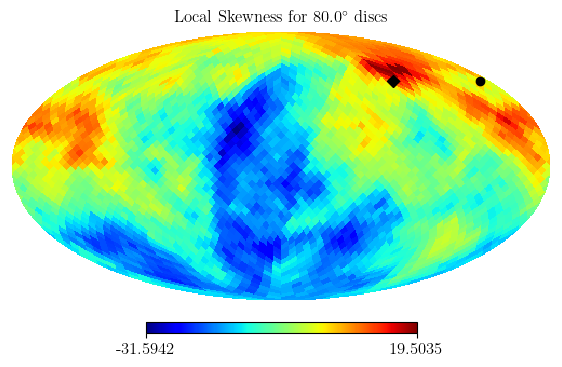

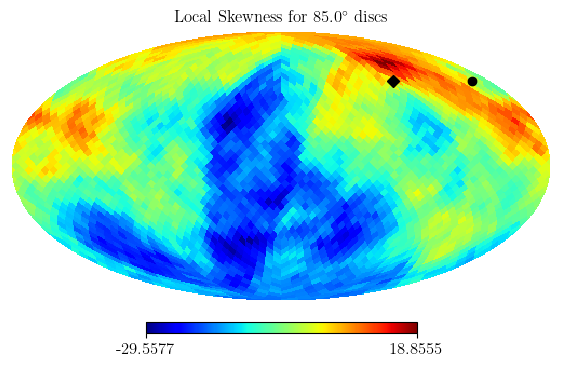

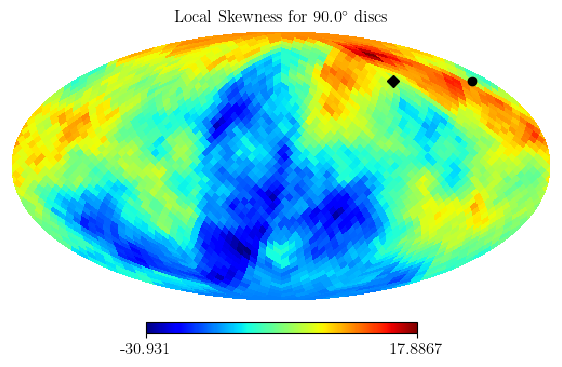

In [ ]:
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

for i, disc_size in enumerate(map_disc_sizes):
    #CMB measure
    '''cmb_msr'''
    cmb_local_msr_map   = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    sims_local_msr_map  = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt")

    cmb_dir     = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", dtype = int)
    sims_dir    = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_dir.txt", dtype = int)
    dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
    lat, lon = dir_lat[cmb_dir[i]], dir_lon[cmb_dir[i]]
    
    #Simulations measure
    sims_msr   = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_{disc_size:02}cap.txt")
    mean_field = np.mean(sims_msr, axis = 0)
    var_msr = np.var(sims_msr, axis = 0)
    # CMB_local_measure_map
    # local_msr_map = (sims_local_msr_map[700] - mean_field) / var_msr
    local_msr_map = (cmb_local_msr_map - mean_field) / var_msr
    _fig, _ax = plt.subplots(ncols=1)

    _fig.set_size_inches(7,5)
    plt.axes(_ax)
    hp.mollview(local_msr_map,
                title = r"Local Skewness for ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
                hold = True,
                # fontsize = dict(title = 20,
                #                 cbar_tick_label = 15)
                )
    hp.projplot(lon_beta, lat_beta, 'kD', lonlat=True)
    hp.projplot(lon, lat, 'ko', lonlat=True)
    custom_save_fig(fig = _fig,
                    fdir = plot_path,
                    fname = "{}_skewnessmap{:02}cap".format(cleaning_pipeline, disc_size),
                    do_plt_save = False)
    plt.show()

### Comparing Dipoles of CMB and Simulations

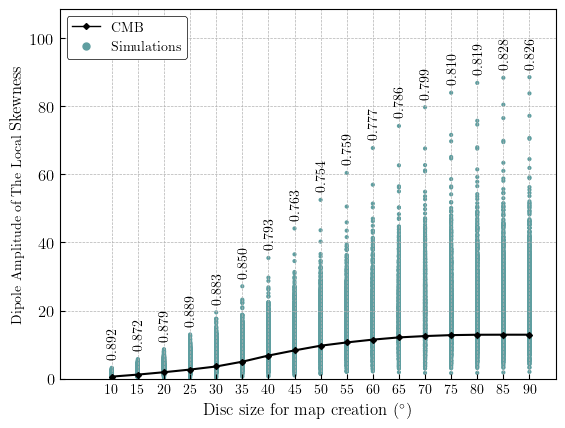

In [86]:
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline
cmb_dip_amp = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_amp.txt")
sims_dip_amp = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_amp.txt")

p_values = np.zeros(len(map_disc_sizes))
for ds_i, disc_size in enumerate(map_disc_sizes):
    p_values[ds_i] = np.sum(sims_dip_amp[ds_i] > cmb_dip_amp[ds_i]) / run_inputs.max_sim_num

# Find Stripe-Method's dipole amplitude
cmb_A1 = np.zeros(len(map_disc_sizes))
sims_A1 = np.zeros((len(map_disc_sizes), run_inputs.max_sim_num))

_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

with plt.style.context('bmh'):
    x_offset = 0.6
    fig, ax = plt.subplots()
    
    for ds_i, disc_size in enumerate(map_disc_sizes):
        ax.scatter(disc_size * np.ones(run_inputs.max_sim_num), sims_dip_amp[ds_i],
                    marker='.', edgecolors='none', linewidths=.5, c='cadetblue', alpha=1)
        ax.text(x=disc_size - 1, y = np.max(sims_dip_amp[ds_i]) + 3,
                s = "{:0.3f}".format(p_values[ds_i]), rotation=90)
    
    ax.plot(map_disc_sizes, cmb_dip_amp,
            color='k', marker='D', markersize=3, linewidth=1.5)

    ax.set_xlabel(r"Disc size for map creation $(^\circ)$")
    ax.set_ylabel(r"\normalsize{Dipole Amplitude of The Local} \large{Skewness}")
    # ax.set_title(r"Comparison between stripe-mean Legendre dipole \& Dipole fitting")
    sample_curves = [
        Line2D([0], [0], ls='-',    color='k',     lw=1, marker='D', markersize=3),
        Line2D([0], [0], ls='none', color='cadetblue',  lw=1, marker='.', markersize=10),
        ]
    ax.legend(  sample_curves, [
                    "CMB",
                    "Simulations",
                ],
                loc=2)
    ax.tick_params(axis='x', which='major', labelsize=10)
    ax.set_xlim(xmin = 0, xmax = 95)
    ax.set_ylim(ymin = 0, ymax = np.max(sims_dip_amp) + 20)
    ax.set_xticks(map_disc_sizes)
    ax.set_facecolor('white')
    # Axis colors
    for spine in ax.spines.keys(): ax.spines[spine].set_color('k')
    plt.show()
    custom_save_fig(fig, fdir = plot_path, fname = "dipole_amplitude_skewness")


## Distribution of dipole amplitudes for each disc-size

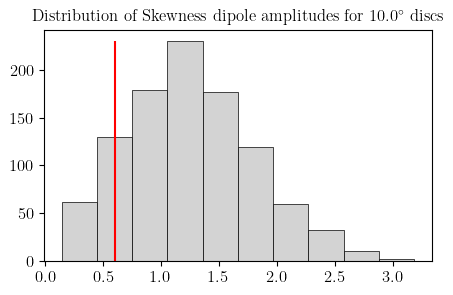

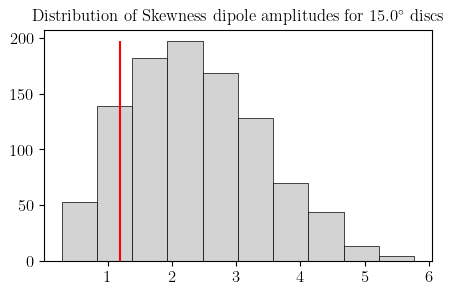

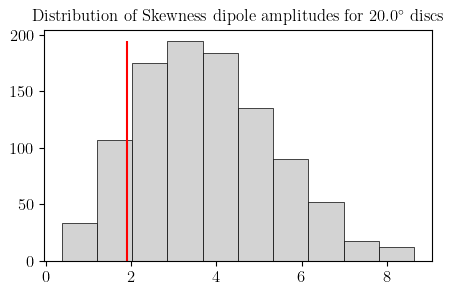

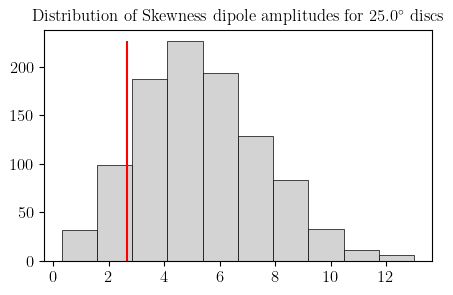

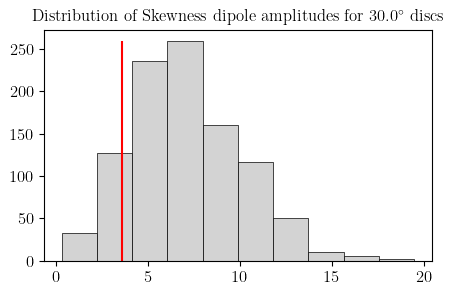

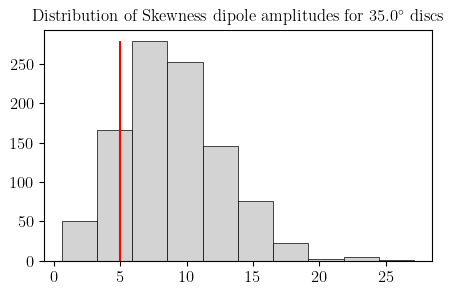

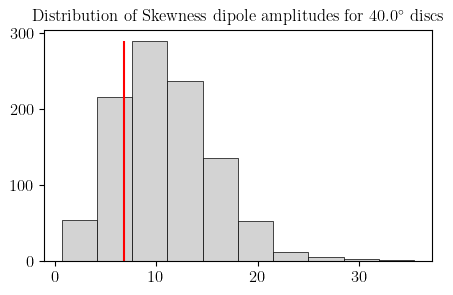

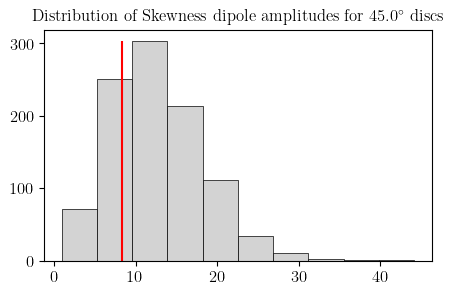

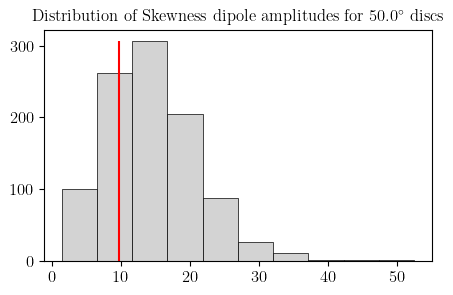

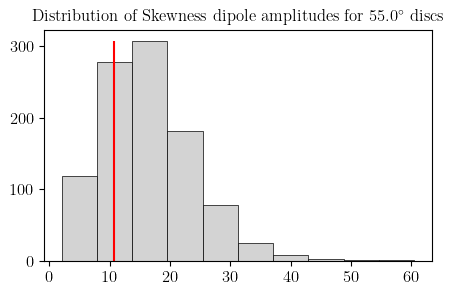

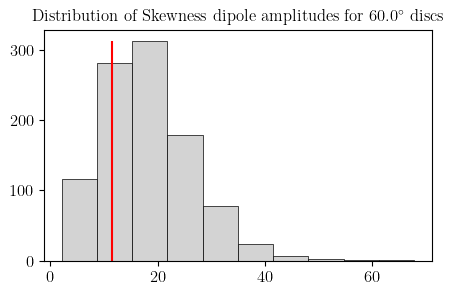

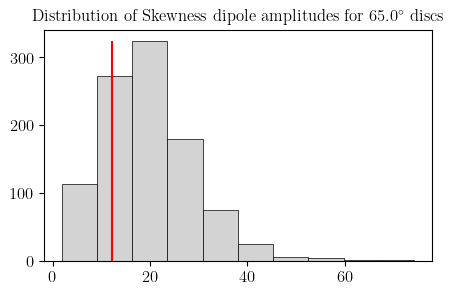

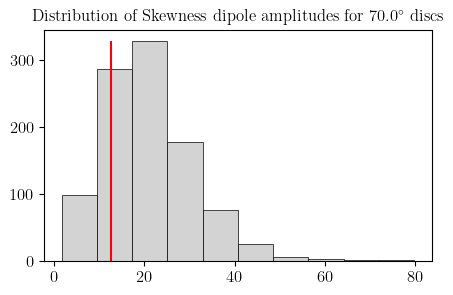

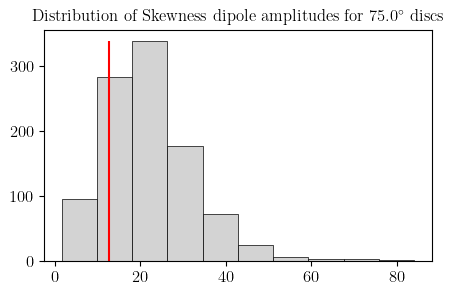

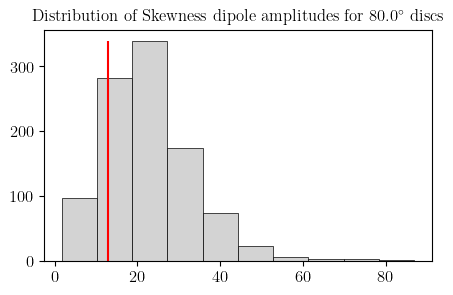

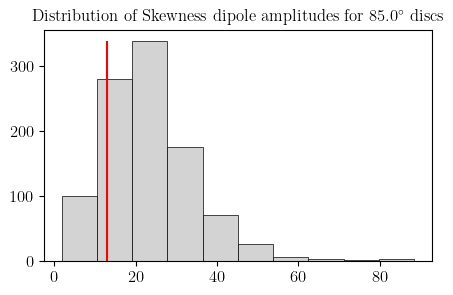

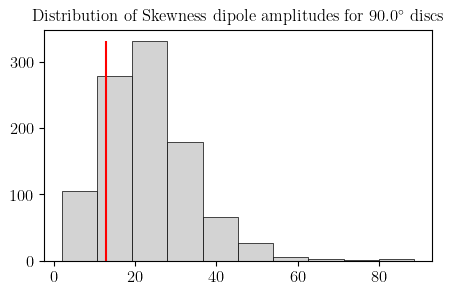

In [108]:
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

cmb_dip_amp = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_amp.txt")
sims_dip_amp = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_amp.txt")

for ds_i, disc_size in enumerate(map_disc_sizes):
    fig, ax = plt.subplots()
    fig.set_size_inches(5,3)
    y, x, _ = ax.hist(sims_dip_amp[ds_i], color = "lightgrey", ec='k', lw=0.5)
    ax.set_title(r"Distribution of Skewness dipole amplitudes for {disc_size}$^\circ$ discs".format(disc_size=disc_size))
    ax.vlines(cmb_dip_amp[ds_i], 0, max(y), colors='r', label='CMB')
    plt.show()

## Dipoles of different disc-sizes

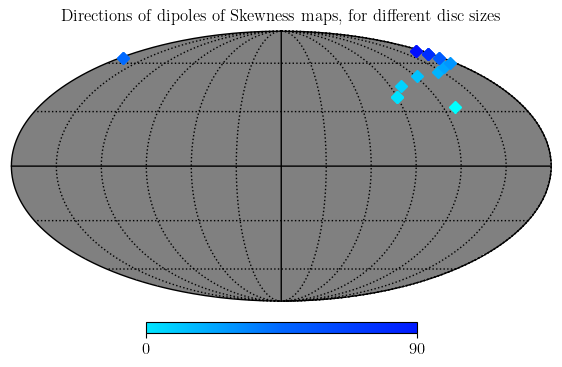

In [69]:
dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

cmb_skew_dir_i    = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_dir.txt", dtype = int)
sims_skew_dir_i   = np.loadtxt(base_path + f"{_series}_sims_{_mflag}_dir.txt", dtype = int)

nsizes = len(map_disc_sizes)

_fig, _ax = plt.subplots(ncols=1)
_fig.set_size_inches(7,5)
colors = [(0, 0.9, 1.0), (0, 0.4, 1), (0.0, 0.1, 1)]
blue_cmap = LinearSegmentedColormap.from_list('blue_cmap', colors, N=256)
hp.mollview(np.array(12*[np.nan]),
            fig=_fig,
            title="Directions of dipoles of Skewness maps, for different disc sizes",
            cmap=blue_cmap,
            min=0,
            max=90,
            hold=True)
hp.graticule()

for i, disc_size in enumerate(map_disc_sizes):
    lat, lon = dir_lat[cmb_skew_dir_i[i]], dir_lon[cmb_skew_dir_i[i]]
    hp.projplot(lon, lat, c = (0, 1-i/nsizes, 1), marker='D', lonlat=True)

plt.show()

## Local Skewness for non-overlapping regions

256.0


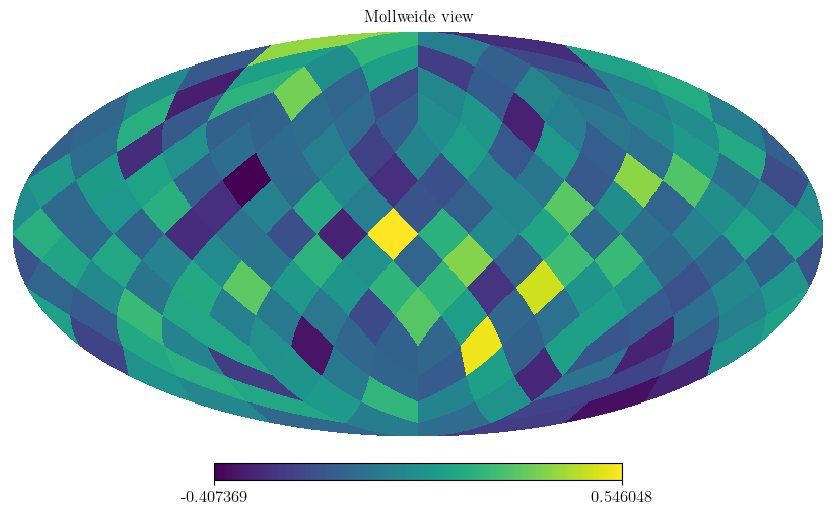

In [26]:
nside_high = 64
nside_low = 4
print((nside_high / nside_low)**2)
index_map_list = cau.coords.get_pixel_indices_lying_on_lower_nside_pixel(nside_high, nside_low)
map_values = np.zeros(hp.nside2npix(nside_low))
for ipix_low in range(len(index_map_list)):
    high_res_indices = index_map_list[ipix_low]
    map_values[ipix_low] = cau.stat_utils.skew(cmb_map.raw_data[high_res_indices])
hp.mollview(map_values)
plt.show()